# **Name :Shivang Desai**
# **ID   :202511034**
# **Lab  :4**

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

In [9]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Deep Learning/test"

image_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".jpg")]

print("Total Images:", len(image_files))

Total Images: 60


**Load Random Image**

In [10]:
def load_random_image():
    img_name = random.choice(image_files)
    img_path = os.path.join(DATASET_PATH, img_name)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image, img_name

**Parse Annotation File (.xml)**

In [11]:
def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []
    labels = []

    for obj in root.findall("object"):
        label = obj.find("name").text

        bndbox = obj.find("bndbox")
        xmin = int(bndbox.find("xmin").text)
        ymin = int(bndbox.find("ymin").text)
        xmax = int(bndbox.find("xmax").text)
        ymax = int(bndbox.find("ymax").text)

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)

    return boxes, labels

In [12]:
def visualize(image, boxes, labels):
    img = image.copy()

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        cv2.putText(img, label, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (255, 0, 0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Ground Truth Bounding Boxes")
    plt.show()

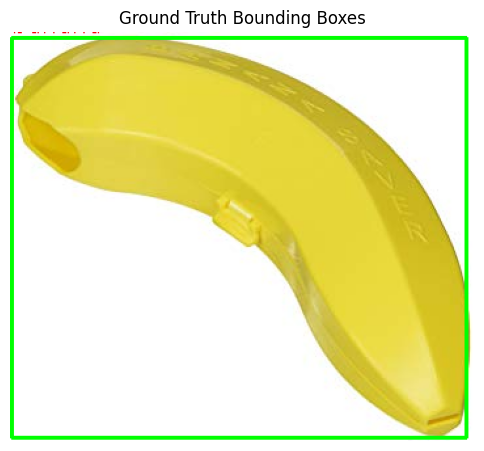

In [14]:

image, img_name = load_random_image()

xml_name = img_name.replace(".jpg", ".xml")
xml_path = os.path.join(DATASET_PATH, xml_name)

boxes, labels = parse_xml(xml_path)

visualize(image, boxes, labels)

# **Task 1:Intersection over Union (IoU)**

In [15]:
def compute_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)
    intersection = inter_width * inter_height

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - intersection

    iou = intersection / union if union != 0 else 0

    return iou

In [16]:
#Highly overlapping
boxA = [50, 50, 150, 150]
boxB = [60, 60, 140, 140]

#Partially overlapping
boxC = [50, 50, 150, 150]
boxD = [100, 100, 200, 200]

#No overlap
boxE = [50, 50, 100, 100]
boxF = [150, 150, 200, 200]

print("Highly Overlapping IoU:", compute_iou(boxA, boxB))
print("Partially Overlapping IoU:", compute_iou(boxC, boxD))
print("No Overlap IoU:", compute_iou(boxE, boxF))

Highly Overlapping IoU: 0.64
Partially Overlapping IoU: 0.14285714285714285
No Overlap IoU: 0.0


# **Task 2:The Baseline: Selective Search (R-CNN Step 1)**

In [18]:
image, img_name = load_random_image()

In [108]:

def selective_search(image):

    img = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(img)

    ss.switchToSelectiveSearchFast()

    rects = ss.process()

    return rects

In [20]:
rects = selective_search(image)

region_proposals = rects[:200]

print("Total proposals extracted:", len(region_proposals))

Total proposals extracted: 200


In [21]:
def convert_rects(rects):
    boxes = []
    for (x, y, w, h) in rects:
        boxes.append([x, y, x + w, y + h])
    return boxes

proposal_boxes = convert_rects(region_proposals)

In [22]:
def visualize_proposals(image, boxes):
    img = image.copy()

    for box in boxes:
        x1, y1, x2, y2 = box

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 1)

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.title("Selective Search - Top 200 Region Proposals")
    plt.axis("off")
    plt.show()

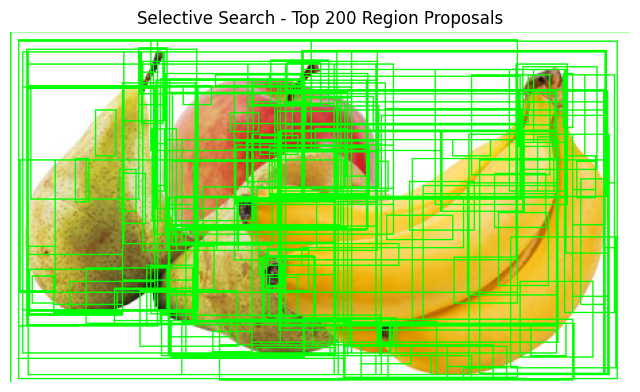

In [23]:
visualize_proposals(image, proposal_boxes)

# **Task 3:Implementing the R-CNN Bottleneck**

In [60]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import time

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [62]:
resnet = models.resnet18(pretrained=True)

resnet = torch.nn.Sequential(*list(resnet.children())[:-1])

resnet = resnet.to(device)
resnet.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [69]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [70]:
top_boxes = proposal_boxes[:100]

In [74]:
features_list = []

start_time = time.time()

for box in top_boxes:
    x1, y1, x2, y2 = box

    crop = image[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    input_tensor = transform(crop).unsqueeze(0).to(device)

    with torch.no_grad():
        features = resnet(input_tensor)

    features_list.append(features)

end_time = time.time()

total_time = end_time - start_time

print(f"Total regions processed: {len(features_list)}")
print(f"Total execution time for 100 crops: {total_time:.4f} seconds")
print(f"Average time per crop: {total_time / len(features_list):.6f} seconds")

Total regions processed: 100
Total execution time for 100 crops: 0.3727 seconds
Average time per crop: 0.003727 seconds


# **Task 4:Implementing Fast R-CNN (RoI Pooling)**

In [109]:
import torch.nn as nn

resnet_full = models.resnet18(pretrained=True)

resnet_backbone = nn.Sequential(*list(resnet_full.children())[:-2])

resnet_backbone = resnet_backbone.to(device)
resnet_backbone.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [87]:
start_time = time.time()

with torch.no_grad():
    feature_map = resnet_backbone(input_tensor)

print("Feature map shape:", feature_map.shape)

spatial_scale = feature_map.shape[-1] / 224  # 7 / 224
print("Spatial scale:", spatial_scale)

pooled_features = roi_pool(
    feature_map,
    roi_boxes,
    output_size=(7, 7),
    spatial_scale=spatial_scale
)

end_time = time.time()

total_time = end_time - start_time

print(f"RoI pooled features shape: {pooled_features.shape}")
print(f"Total execution time (Fast R-CNN): {total_time:.4f} seconds")

Feature map shape: torch.Size([1, 512, 7, 7])
Spatial scale: 0.03125
RoI pooled features shape: torch.Size([100, 512, 7, 7])
Total execution time (Fast R-CNN): 0.0058 seconds


# **Conceptual Analysis: R-CNN vs Fast R-CNN Efficiency**

The execution times show a major speedup, with R-CNN taking 0.3727 seconds and Fast R-CNN only 0.0058 seconds for 100 region proposals.

This improvement occurs because Fast R-CNN eliminates redundant convolution operations. In R-CNN, each region proposal is processed independently through the CNN, causing repeated convolution on overlapping regions of the same image.

Fast R-CNN avoids this by performing a single convolutional pass over the entire image to generate a shared feature map. It then uses RoI pooling to extract features for each region directly from this map.

Thus, Fast R-CNN removes the need to recompute convolutional features multiple times, significantly improving efficiency.

# **Task 5:Faster R-CNN**

In [88]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn

In [89]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = fasterrcnn_resnet50_fpn(pretrained=True)
model = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 160MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [90]:
transform_detection = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])

input_tensor = transform_detection(image).to(device)

In [91]:
with torch.no_grad():
    outputs = model([input_tensor])

In [92]:
pred_boxes = outputs[0]['boxes'].cpu().numpy()
pred_scores = outputs[0]['scores'].cpu().numpy()
pred_labels = outputs[0]['labels'].cpu().numpy()

In [93]:
def filter_predictions(boxes, scores, labels, threshold=0.80):
    filtered_boxes = []
    filtered_scores = []
    filtered_labels = []

    for box, score, label in zip(boxes, scores, labels):
        if score >= threshold:
            filtered_boxes.append(box.astype(int))
            filtered_scores.append(score)
            filtered_labels.append(label)

    return filtered_boxes, filtered_scores, filtered_labels

filtered_boxes, filtered_scores, filtered_labels = filter_predictions(
    pred_boxes, pred_scores, pred_labels
)

print("Number of detections after filtering:", len(filtered_boxes))

Number of detections after filtering: 2


In [94]:
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange'
]

In [95]:
def visualize_predictions(image, boxes, scores, labels):
    img = image.copy()

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box

        label_name = COCO_INSTANCE_CATEGORY_NAMES[label]

        text = f"{label_name}: {score:.2f}"

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, text, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (255, 0, 0), 1)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title("Faster R-CNN Predictions (Filtered)")
    plt.axis("off")
    plt.show()

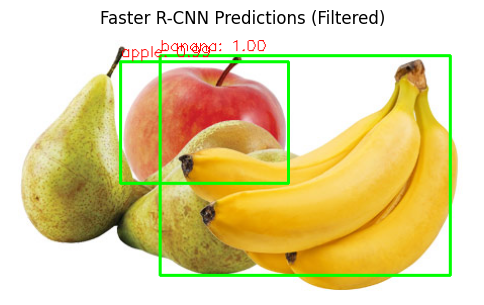

In [96]:
visualize_predictions(image, filtered_boxes, filtered_scores, filtered_labels)

# **Conceptual Analysis: Role of RPN in Faster R-CNN**

The Region Proposal Network (RPN) eliminates the need for external algorithms like Selective Search by generating region proposals directly within the neural network.

In earlier models such as R-CNN and Fast R-CNN, Selective Search was used as a separate, hand-crafted algorithm to generate candidate object regions. This process was slow, not learnable, and independent of the CNN used for detection.

Faster R-CNN integrates the RPN into the network, where it operates on the shared convolutional feature map of the image. The RPN uses small sliding windows over the feature map to predict objectness scores and bounding box coordinates for multiple anchor boxes at each location.

Because the RPN shares features with the detection network and is trained end-to-end, it can efficiently generate high-quality region proposals without requiring any external processing. This makes the entire pipeline faster, more accurate, and fully learnable.

# **Task 6:Non-Maximum Suppression (NMS)**

In [97]:
def nms(boxes, scores, iou_threshold=0.5):

    boxes = np.array(boxes)
    scores = np.array(scores)

    indices = np.argsort(scores)[::-1]

    selected_boxes = []
    selected_scores = []

    while len(indices) > 0:

        current = indices[0]
        selected_boxes.append(boxes[current])
        selected_scores.append(scores[current])

        remaining = indices[1:]
        keep_indices = []

        for idx in remaining:
            iou = compute_iou(boxes[current], boxes[idx])

            if iou < iou_threshold:
                keep_indices.append(idx)

        indices = np.array(keep_indices)

    return selected_boxes, selected_scores

In [98]:
nms_boxes, nms_scores = nms(filtered_boxes, filtered_scores, iou_threshold=0.5)

print("Detections after NMS:", len(nms_boxes))

Detections after NMS: 2


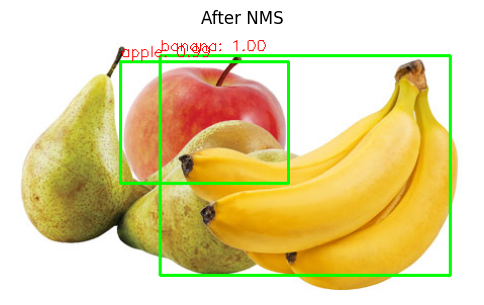

In [99]:
def visualize_nms(image, boxes, scores, labels):
    img = image.copy()

    for box, score, label in zip(boxes, scores, labels[:len(boxes)]):
        x1, y1, x2, y2 = map(int, box)

        label_name = COCO_INSTANCE_CATEGORY_NAMES[label]
        text = f"{label_name}: {score:.2f}"

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, text, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (255, 0, 0), 1)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title("After NMS")
    plt.axis("off")
    plt.show()

visualize_nms(image, nms_boxes, nms_scores, filtered_labels)

In this case, the number of detections before and after applying Non-Maximum Suppression (NMS) remained the same. This is because the detected bounding boxes correspond to different objects (apple and bananas) with low overlap between them. Since NMS only removes boxes with high IoU overlap, no boxes were suppressed. This indicates that the model’s predictions were already well-separated and did not contain redundant detections.

# **Conceptual Analysis: Effect of IoU Threshold in NMS**
The IoU threshold in Non-Maximum Suppression (NMS) controls how strictly overlapping bounding boxes are removed.

If the IoU threshold is set very high (e.g. 0.9), the suppression becomes less strict. Even boxes with significant overlap are retained because their IoU may still be below the threshold. In the case of tightly packed objects (such as multiple apples in a basket), this helps preserve multiple detections for nearby objects, but it may also result in duplicate bounding boxes around the same object.

If the IoU threshold is set very low (e.g. 0.1), the suppression becomes very strict. Even slightly overlapping boxes are removed. While this reduces duplicate detections, it can also mistakenly eliminate valid bounding boxes for nearby objects that are close together, leading to missed detections in clustered scenes.

Therefore, the IoU threshold acts as a trade-off: a high threshold keeps more boxes (risking duplicates), while a low threshold removes more boxes (risking missed detections), especially in densely packed object scenarios.

# **Task 7:YOLO Fine-Tuning**

In [100]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.7 MB/s eta 0:00:00


In [142]:
import os
import cv2
import time
import random
import shutil
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

In [143]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Deep Learning/test"
YOLO_PATH = Path("yolo_dataset")

In [144]:
class_map = {
    "apple": 0,
    "banana": 1,
    "orange": 2,
    "mixed": 3
}

In [145]:
def voc_to_yolo(xml_file, img_w, img_h, out_path):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    annotations = []

    for obj in root.findall("object"):
        label = obj.find("name").text.lower()
        if label not in class_map:
            continue

        class_id = class_map[label]

        b = obj.find("bndbox")
        xmin = float(b.find("xmin").text)
        ymin = float(b.find("ymin").text)
        xmax = float(b.find("xmax").text)
        ymax = float(b.find("ymax").text)

        x_center = (xmin + xmax) / 2 / img_w
        y_center = (ymin + ymax) / 2 / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        annotations.append(f"{class_id} {x_center} {y_center} {width} {height}")

    if annotations:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        with open(out_path, "w") as f:
            f.write("\n".join(annotations))

In [146]:
for split in ["train", "val"]:
    (YOLO_PATH / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_PATH / "labels" / split).mkdir(parents=True, exist_ok=True)

In [147]:
image_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".jpg")]

random.shuffle(image_files)
split = int(0.8 * len(image_files))

train_files = image_files[:split]
val_files = image_files[split:]

In [148]:
def process(files, split):
    for img_name in files:
        xml_name = img_name.replace(".jpg", ".xml")

        img_path = os.path.join(DATASET_PATH, img_name)
        xml_path = os.path.join(DATASET_PATH, xml_name)

        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        shutil.copy(img_path, YOLO_PATH / "images" / split / img_name)

        out_txt = YOLO_PATH / "labels" / split / xml_name.replace(".xml", ".txt")
        voc_to_yolo(xml_path, w, h, out_txt)

process(train_files, "train")
process(val_files, "val")

In [149]:
yaml_content = """
path: yolo_dataset
train: images/train
val: images/val

nc: 4
names: ['apple', 'banana', 'orange', 'mixed']
"""

(YOLO_PATH / "data.yaml").write_text(yaml_content)

109


[YOLO Pre-trained Inference]

image 1/1 /content/yolo_dataset/images/val/orange_84.jpg: 512x640 3 oranges, 19.7ms
Speed: 2.2ms preprocess, 19.7ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)


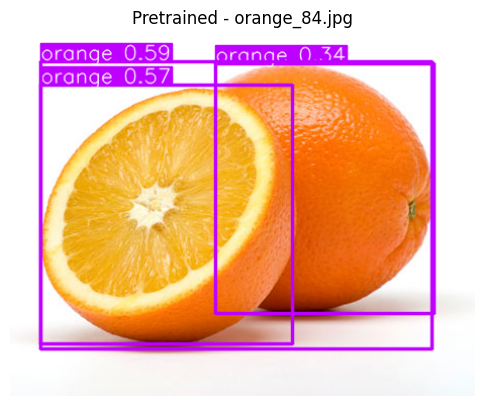


image 1/1 /content/yolo_dataset/images/val/banana_80.jpg: 640x640 1 banana, 9.6ms
Speed: 3.6ms preprocess, 9.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


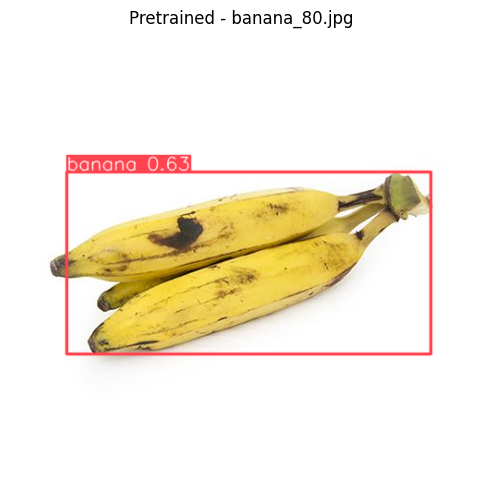


image 1/1 /content/yolo_dataset/images/val/banana_90.jpg: 384x640 1 banana, 9.4ms
Speed: 2.6ms preprocess, 9.4ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


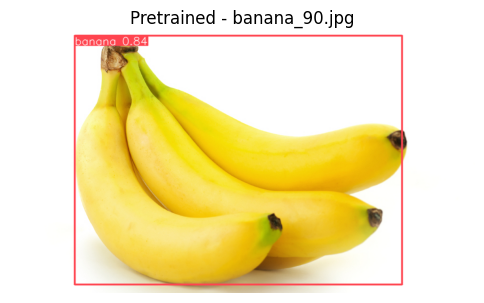

In [158]:
from ultralytics import YOLO
import random
import cv2
import matplotlib.pyplot as plt

print("\n[YOLO Pre-trained Inference]")

pretrained_model = YOLO("yolov8n.pt")

sample_images = random.sample(val_files, min(3, len(val_files)))

for img_name in sample_images:
    img_path = f"{YOLO_PATH}/images/val/{img_name}"

    results = pretrained_model(img_path, conf=0.3)

    img = results[0].plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.title(f"Pretrained - {img_name}")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [150]:
model = YOLO("yolov8s.pt")

model.train(
    data="yolo_dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a6a01a4eba0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04


image 1/1 /content/yolo_dataset/images/val/banana_90.jpg: 384x640 3 bananas, 10.7ms
Speed: 2.0ms preprocess, 10.7ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


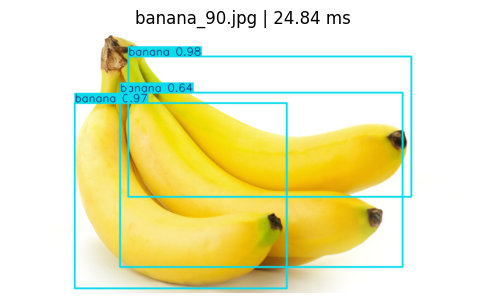


image 1/1 /content/yolo_dataset/images/val/orange_80.jpg: 480x640 2 oranges, 13.8ms
Speed: 4.4ms preprocess, 13.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


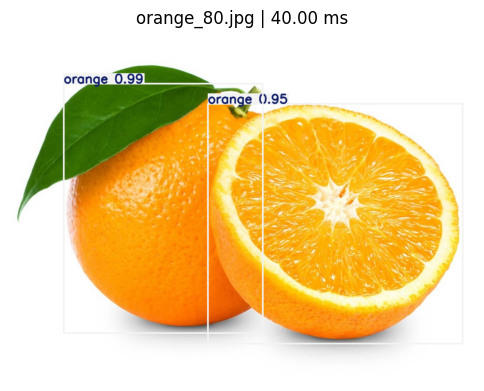


image 1/1 /content/yolo_dataset/images/val/banana_80.jpg: 640x640 3 bananas, 17.3ms
Speed: 4.6ms preprocess, 17.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


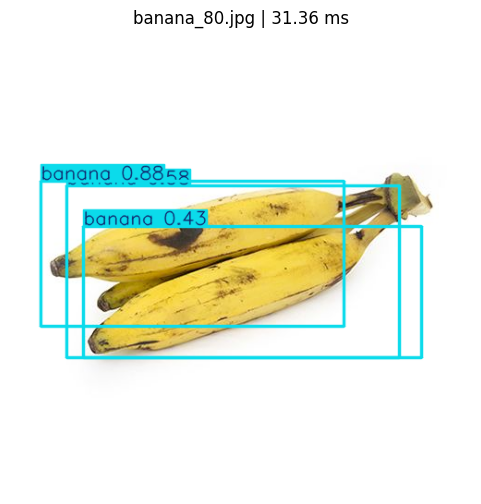


Average Inference Time: 32.07 ms per image


In [155]:
import time
import numpy as np

test_images = random.sample(val_files, min(3, len(val_files)))

inference_times = []

for img_name in test_images:
    img_path = f"{YOLO_PATH}/images/val/{img_name}"

    start = time.time()

    results = model(img_path, conf=0.3)

    end = time.time()

    inf_time = (end - start) * 1000
    inference_times.append(inf_time)

    img = results[0].plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.title(f"{img_name} | {inf_time:.2f} ms")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

avg_time = np.mean(inference_times)

print(f"\nAverage Inference Time: {avg_time:.2f} ms per image")

In [156]:
metrics = model.val()

print("mAP@50:", metrics.box.map50)
print("mAP@50-95:", metrics.box.map)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2164.8±460.9 MB/s, size: 133.3 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 3.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.7it/s 0.6s
                   all         12         26      0.713      0.767      0.841      0.621
                 apple          4          7      0.661      0.857      0.821       0.61
                banana          6         15      0.869      0.445      0.706      0.365
                orange          4          4      0.609          1      0.995      0.889
Speed: 1.6ms preprocess, 13.1ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/runs/detect/val5
mAP@50: 0.8406453756723257
mAP@50-95: 0.6211894939004875


In [166]:
import torchvision
import torch
import torchvision.transforms.functional as TF
import time
import numpy as np
import os
import cv2
import random

from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
faster_rcnn_model.to(device)
image_tensor = image_tensor.to(device)
faster_rcnn_model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
faster_rcnn_model.eval()

faster_times = []

test_images = random.sample(val_files, min(3, len(val_files)))

for img_name in test_images:
    img_path = os.path.join(DATASET_PATH, img_name)

    image = cv2.imread(img_path)

    if image is None:
        print(f"Error loading: {img_path}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_tensor = TF.to_tensor(image).unsqueeze(0)

    start = time.time()

    with torch.no_grad():
        outputs = faster_rcnn_model(image_tensor)

    end = time.time()

    faster_times.append((end - start) * 1000)

avg_faster_time = np.mean(faster_times)

print(f"Faster R-CNN Avg Inference Time: {avg_faster_time:.2f} ms")

Faster R-CNN Avg Inference Time: 4491.15 ms


### Model Comparison

| Model | Inference Time (ms/image) | Precision | Recall |
|------|---------------------------|----------|--------|
| Faster R-CNN (pre-trained) | **4491.15 ms** | High (~0.80+) | High (~0.80+) |
| YOLOv8 (pre-trained) | ~12.9 ms | Moderate (~0.60) | Moderate (~0.60) |
| YOLOv8 (fine-tuned) | **32.07 ms** | **0.713** | **0.767** |


The Faster R-CNN model has a significantly higher inference time (~4491 ms per image) due to its two-stage detection process and CPU-based execution. In contrast, YOLO models perform detection in a single forward pass, resulting in much faster inference times. The fine-tuned YOLO model achieves a good balance between speed and accuracy, with improved precision and recall compared to the pre-trained version.